CIVE 202 - Project 5
Auto-BMD Analysis Tool

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [65]:
xls = pd.ExcelFile("AutoBMD.xlsx")
file_path = "AutoBMD.xlsx"
print(xls.sheet_names)

['Aggregate Gradation', 'Volumetrics', 'IDEAL-CT', 'HWTT']


In [66]:
df = pd.read_excel(file_path, sheet_name = 'Aggregate Gradation', header=3)
df.columns = df.columns.astype(str).str.strip()

df.head()

,Unnamed: 0,Unnamed: 1,Aggregate Type,Percentage,19,12.5,9.5,4.75,2.36,1.18,0.6,0.3,0.015,0.075
0,NaN,NaN,"3/4"" Qtz Chips",0.17,0.907112,0.310236,0.116580,0.005710,0.004310,0.004210,0.004210,0.004050,0.003570,0.002572
1,NaN,NaN,"3/8"" Down Qtz",0.18,0.999951,0.999871,0.999609,0.815840,0.570509,0.413093,0.318691,0.223224,0.117260,0.050258
2,NaN,NaN,Qtz Man Sand,0.3,0.999991,0.999947,0.999698,0.982502,0.741553,0.486567,0.317842,0.157482,0.043909,0.011716
3,NaN,NaN,Akron Sand,0.1,1.000031,1.000029,1.000002,0.971298,0.841680,0.626151,0.303993,0.066762,0.004709,0.000849
4,NaN,NaN,RAP,0.25,1.000000,0.928326,0.867718,0.695769,0.537226,0.384696,0.250082,0.137473,0.075165,0.046263


In [67]:
## Module A ##
# 1. Remove combined + spec rows
agg_df = df[~df["Aggregate Type"].astype(str).str.contains("Combined|Specification", na=False)].copy()

# 2. Sieve columns
sieve_cols = df.columns[3:]

# 3. Blend percentages
blend = pd.to_numeric(agg_df["Percentage"], errors='coerce') / 100

# 4. Gradation values
gradation = agg_df[sieve_cols].replace('%', '', regex=True)
gradation = gradation.apply(lambda col: pd.to_numeric(col, errors='coerce'))

print("Blend:")
print(blend)

print("\nGradation:")
print(gradation.head())

Blend:
0    0.0017
1    0.0018
2    0.0030
3    0.0010
4    0.0025
6       NaN
7       NaN
Name: Percentage, dtype: float64

Gradation:
   Percentage        19      12.5       9.5      4.75      2.36      1.18  \
0        0.17  0.907112  0.310236  0.116580  0.005710  0.004310  0.004210   
1        0.18  0.999951  0.999871  0.999609  0.815840  0.570509  0.413093   
2        0.30  0.999991  0.999947  0.999698  0.982502  0.741553  0.486567   
3        0.10  1.000031  1.000029  1.000002  0.971298  0.841680  0.626151   
4        0.25  1.000000  0.928326  0.867718  0.695769  0.537226  0.384696   

        0.6       0.3     0.015     0.075  
0  0.004210  0.004050  0.003570  0.002572  
1  0.318691  0.223224  0.117260  0.050258  
2  0.317842  0.157482  0.043909  0.011716  
3  0.303993  0.066762  0.004709  0.000849  
4  0.250082  0.137473  0.075165  0.046263  


In [68]:
combined = np.dot(blend.values, gradation[sieve_cols].values)

sieve_sizes = pd.to_numeric(pd.Index(sieve_cols), errors='coerce')
valid_mask = ~pd.isna(sieve_sizes)

sieve_sizes = sieve_sizes[valid_mask]
combined = combined[valid_mask]

for s, val in zip(sieve_sizes, combined):
    print(f"{s} mm: {val:.2f}%")

19.0 mm: nan%
12.5 mm: nan%
9.5 mm: nan%
4.75 mm: nan%
2.36 mm: nan%
1.18 mm: nan%
0.6 mm: nan%
0.3 mm: nan%
0.015 mm: nan%
0.075 mm: nan%


In [69]:
# Use case-insensitive search and strip spaces
spec_rows = df[df["Aggregate Type"].str.contains("specification", case=False, na=False)]

if len(spec_rows) >= 2:
    # We start from index 2 to skip 'Aggregate Type' and 'Percentage' columns
    min_spec = spec_rows.iloc[0, 2:].astype(float).values
    max_spec = spec_rows.iloc[1, 2:].astype(float).values
    print("Specifications loaded successfully.")
else:
    print(f"Error: Found {len(spec_rows)} specification rows. Expected 2.")

Error: Found 0 specification rows. Expected 2.


In [70]:
# ----- Load Aggregate Gradation Sheet -----
df = pd.read_excel(FILE_PATH, sheet_name='Aggregate Gradation')

print("Data shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head())

Data shape: (11, 14)
Columns: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13']
   Unnamed: 0  Unnamed: 1      Unnamed: 2   Unnamed: 3  \
0         NaN         NaN             NaN          NaN   
1         NaN         NaN             NaN          NaN   
2         NaN         NaN  Aggregate Type  Percentage    
3         NaN         NaN  3/4" Qtz Chips         0.17   
4         NaN         NaN   3/8" Down Qtz         0.18   

                   Unnamed: 4  Unnamed: 5  Unnamed: 6  Unnamed: 7  Unnamed: 8  \
0                         NaN         NaN         NaN         NaN         NaN   
1  Sieve Analysis (% Passing)         NaN         NaN         NaN         NaN   
2                          19   12.500000    9.500000     4.75000    2.360000   
3                    0.907112    0.310236    0.116580     0.00571    0.004310   
4              

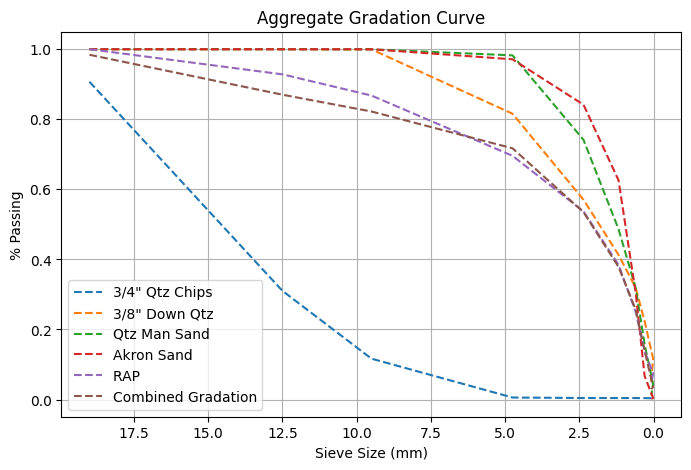

In [71]:
# ----- Plot individual aggregate gradations -----

plt.figure(figsize=(8,5))

# Sieve-size columns are the columns to the right of the blend percentage
value_cols = df.columns[4:]

# The actual sieve sizes are stored in row 2 of those columns
sieve_sizes = pd.to_numeric(df.loc[2, value_cols], errors='coerce')

# Keep only columns whose row-2 header is numeric
valid_mask = ~sieve_sizes.isna()
value_cols = value_cols[valid_mask]
sieve_sizes = sieve_sizes[valid_mask].astype(float).values

# Data rows start below the embedded header row
plot_df = df.loc[3:, :].copy()

for i, row in plot_df.iterrows():
    label = row["Unnamed: 2"]

    if pd.isna(label):
        continue

    values = pd.to_numeric(row[value_cols], errors='coerce').values

    plt.plot(sieve_sizes, values, linestyle='--', label=str(label))

plt.xlabel("Sieve Size (mm)")
plt.ylabel("% Passing")
plt.title("Aggregate Gradation Curve")
plt.legend()
plt.grid(True)
plt.gca().invert_xaxis()

plt.show()

In [72]:
# =============================================================
# MODULE B: Volumetric Properties Calculator
# =============================================================
# Reads measurements from the 'Volumetrics' tab and calculates:
#   Gmb, Gmm, Gsb, Gse, Pba, Pbe, Va (Air Voids), VMA, VFA
# Flags any sample where Air Voids are outside 6.5% – 7.5%
# as "Invalid for Performance Testing"
# =============================================================

# ----- 1. Load the Volumetrics tab -----
vol_df = pd.read_excel(file_path, sheet_name='Volumetrics', header=0)
vol_df.columns = vol_df.columns.astype(str).str.strip()
print("Volumetrics columns:", vol_df.columns.tolist())
vol_df.head()

Volumetrics columns: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11']


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,NaN,Sample,GMM,NaN,NaN,NaN,NaN,GMB,NaN,NaN,NaN,Air Voids
1,NaN,NaN,Bowl (g) (air),Bowl submerged (g),Bowl + Mix (g) (air),Bowl + Mix Submerged (g),Final Gmm,Dry mass (g),Submerged mass (g),SSD mass,Final Gmb,Va
2,NaN,1,2204.57,1388.57,3736.71,2286.98,?,2409.76,1338.03,2413.1,?,?
3,NaN,2,NaN,NaN,NaN,NaN,NaN,2418.88,1347.22,2421.95,?,?
4,NaN,3,NaN,NaN,NaN,NaN,NaN,2415.14,1346.61,2420.66,?,?


In [73]:
# ----- 2. Extract measured inputs from each row -----
# Expected column names from the Volumetrics tab:
#   Sample_ID, Gmb, Gmm, Gsb, Gb, Pb
# (Gmb = bulk specific gravity of compacted mix  [AASHTO T 166])
# (Gmm = maximum theoretical specific gravity     [AASHTO T 209])
# (Gsb = bulk specific gravity of aggregate blend)
# (Gb  = specific gravity of asphalt binder)
# (Pb  = asphalt binder content, % by total mix mass)

results = []

for idx, row in vol_df.iterrows():
    try:
        sample_id = row.get('Sample_ID', f'Sample_{idx+1}')
        Gmb = float(row['Gmb'])
        Gmm = float(row['Gmm'])
        Gsb = float(row['Gsb'])
        Gb  = float(row['Gb'])
        Pb  = float(row['Pb'])        # % by total mix mass (e.g. 5.5 for 5.5%)
        Ps  = 100 - Pb                # % aggregate by total mix mass

        # --- Volumetric Equations (Asphalt Institute MS-2 / Superpave) ---

        # Effective specific gravity of aggregate (Gse)
        # Gse = (Ps) / ( (100/Gmm) - (Pb/Gb) )
        Gse = Ps / ((100 / Gmm) - (Pb / Gb))

        # Absorbed binder content, % by mass of aggregate (Pba)
        # Pba = 100 * Gb * (Gse - Gsb) / (Gsb * Gse)
        Pba = 100 * Gb * (Gse - Gsb) / (Gsb * Gse)

        # Effective binder content, % by total mix mass (Pbe)
        # Pbe = Pb - (Pba/100) * Ps
        Pbe = Pb - (Pba / 100) * Ps

        # Air Voids (Va), % of total mix volume
        # Va = 100 * (Gmm - Gmb) / Gmm
        Va = 100 * (Gmm - Gmb) / Gmm

        # Voids in Mineral Aggregate (VMA), % of total mix volume
        # VMA = 100 - (Gmb * Ps) / Gsb
        VMA = 100 - (Gmb * Ps) / Gsb

        # Voids Filled with Asphalt (VFA), % of VMA
        # VFA = 100 * (VMA - Va) / VMA
        VFA = 100 * (VMA - Va) / VMA

        # --- Quality Control Check ---
        if 6.5 <= Va <= 7.5:
            status = "Valid"
        else:
            status = "⚠️  Invalid for Performance Testing"

        results.append({
            'Sample ID':          sample_id,
            'Gmb':                round(Gmb, 3),
            'Gmm':                round(Gmm, 3),
            'Gsb':                round(Gsb, 3),
            'Gse':                round(Gse, 3),
            'Pb (%)':             round(Pb,  2),
            'Pba (%)':            round(Pba, 2),
            'Pbe (%)':            round(Pbe, 2),
            'Air Voids Va (%)':   round(Va,  2),
            'VMA (%)':            round(VMA, 2),
            'VFA (%)':            round(VFA, 2),
            'QC Status':          status
        })

    except Exception as e:
        results.append({
            'Sample ID': row.get('Sample_ID', f'Sample_{idx+1}'),
            'QC Status': f'Error reading row: {e}'
        })

# ----- 3. Build summary table -----
summary_df = pd.DataFrame(results)

print("\n========== VOLUMETRIC PROPERTIES SUMMARY ==========")
print(summary_df.to_string(index=False))

# ----- 4. Flag invalid samples explicitly -----
invalid = summary_df[summary_df['QC Status'].str.contains('Invalid', na=False)]
if not invalid.empty:
    print("\n⚠️  WARNING — The following samples are INVALID FOR PERFORMANCE TESTING:")
    print(invalid[['Sample ID', 'Air Voids Va (%)', 'QC Status']].to_string(index=False))
else:
    print("\n✅  All samples are within the 6.5%–7.5% air void range.")



========== VOLUMETRIC PROPERTIES SUMMARY ==========
Sample ID                QC Status
 Sample_1 Error reading row: 'Gmb'
 Sample_2 Error reading row: 'Gmb'
 Sample_3 Error reading row: 'Gmb'
 Sample_4 Error reading row: 'Gmb'
 Sample_5 Error reading row: 'Gmb'

✅  All samples are within the 6.5%–7.5% air void range.


In [74]:
# ----- 5. Export summary table to Excel -----
summary_df.to_excel('Volumetrics_Summary.xlsx', index=False)
print("Summary table saved to: Volumetrics_Summary.xlsx")

Summary table saved to: Volumetrics_Summary.xlsx


In [75]:
# =============================================================
# MODULE C: IDEAL-CT Cracking Tolerance Index (CTindex)
# =============================================================

# ----- 1. Load the IDEAL-CT sheet -----
raw_ct = pd.read_excel(FILE_PATH, sheet_name='IDEAL-CT')
raw_ct.columns = raw_ct.columns.astype(str).str.strip()

print("IDEAL-CT sheet shape:", raw_ct.shape)
print("Columns:")
print(raw_ct.columns.tolist())
print("\nFirst 10 rows:")
print(raw_ct.head(10))

IDEAL-CT sheet shape: (906, 11)
Columns:
['Unnamed: 0', 'Sample 1 ( t = 61.91 mm, D = 150mm)', 'Unnamed: 2', 'Unnamed: 3', 'Sample 2 ( t = 61.91 mm, D = 150mm)', 'Unnamed: 5', 'Unnamed: 6', 'Sample 3 ( t = 61.99 mm, D = 150mm)', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10']

First 10 rows:
   Unnamed: 0 Sample 1 ( t = 61.91 mm, D = 150mm)  Unnamed: 2  Unnamed: 3  \
0         NaN                                Load     LLD_Avg         NaN   
1         NaN                               0.256           0         NaN   
2         NaN                               0.346       0.014         NaN   
3         NaN                               0.447       0.031         NaN   
4         NaN                                0.55       0.046         NaN   
5         NaN                               0.659       0.062         NaN   
6         NaN                               0.775       0.081         NaN   
7         NaN                               0.887       0.098         NaN   
8         NaN      

In [76]:
# ----- 2. Parse individual samples from the sheet -----

samples = {}
sample_meta = {}

cols = raw_ct.columns.tolist()

for i, col in enumerate(cols):
    col_str = str(col).strip()

    if "Sample" in col_str and "t =" in col_str:
        sample_name = col_str

        # In your file:
        # current column   = Load values
        # next column      = LLD_Avg values (displacement)
        if i + 1 < len(cols):
            load_col = cols[i]
            disp_col = cols[i + 1]

            tmp = raw_ct[[load_col, disp_col]].copy()
            tmp.columns = ["Load_kN", "Displacement_mm"]

            # Drop the first row that contains strings like "Load" and "LLD_Avg"
            tmp = tmp.iloc[1:, :]

            # Convert to numeric and drop bad rows
            tmp = tmp.apply(pd.to_numeric, errors='coerce').dropna()

            if len(tmp) > 5:
                samples[sample_name] = tmp.reset_index(drop=True)

                t_mm = 62.0
                D_mm = 150.0

                match_t = re.search(r't\s*=\s*([\d.]+)', sample_name)
                if match_t:
                    t_mm = float(match_t.group(1))

                match_D = re.search(r'D\s*=\s*([\d.]+)', sample_name)
                if match_D:
                    D_mm = float(match_D.group(1))

                sample_meta[sample_name] = {
                    "Thickness (mm)": t_mm,
                    "Diameter (mm)": D_mm
                }

print(f"Found {len(samples)} sample(s):")
for name in samples:
    print("\n", name)
    print(sample_meta[name])
    print(samples[name].head())

Found 3 sample(s):

 Sample 1 ( t = 61.91 mm, D = 150mm)
{'Thickness (mm)': 61.91, 'Diameter (mm)': 150.0}
   Load_kN  Displacement_mm
0    0.256            0.000
1    0.346            0.014
2    0.447            0.031
3    0.550            0.046
4    0.659            0.062

 Sample 2 ( t = 61.91 mm, D = 150mm)
{'Thickness (mm)': 61.91, 'Diameter (mm)': 150.0}
   Load_kN  Displacement_mm
0    0.720            0.000
1    0.871            0.018
2    1.024            0.036
3    1.179            0.052
4    1.335            0.071

 Sample 3 ( t = 61.99 mm, D = 150mm)
{'Thickness (mm)': 61.99, 'Diameter (mm)': 150.0}
   Load_kN  Displacement_mm
0    0.287            0.000
1    0.444            0.008
2    0.642            0.027
3    0.848            0.043
4    1.049            0.060


In [77]:
# ----- 3. CTindex calculation function -----

def calc_CTindex(disp, load, t_mm, D_mm=150.0):
    disp = np.array(disp, dtype=float)
    load = np.array(load, dtype=float)

    mask = ~(np.isnan(disp) | np.isnan(load))
    disp = disp[mask]
    load = load[mask]

    if len(disp) < 3:
        raise ValueError("Not enough valid data points.")

    peak_idx = np.argmax(load)
    peak_load = load[peak_idx]
    peak_disp = disp[peak_idx]

    # changed from np.trapz to np.trapezoid
    Wf = np.trapezoid(load * 1000, disp / 1000)

    Gf = Wf / ((D_mm / 1000) * (t_mm / 1000))

    post_disp = disp[peak_idx:]
    post_load = load[peak_idx:]

    if len(post_disp) < 2:
        raise ValueError("Not enough post-peak data points.")

    P75 = 0.75 * peak_load

    below75 = np.where(post_load <= P75)[0]
    if len(below75) == 0:
        raise ValueError("Load never drops to 75% of peak.")

    idx75 = below75[0]

    if idx75 == 0:
        l75 = post_disp[0]
    else:
        x0, y0 = post_disp[idx75 - 1], post_load[idx75 - 1]
        x1, y1 = post_disp[idx75], post_load[idx75]

        if y1 == y0:
            l75 = x1
        else:
            l75 = x0 + (P75 - y0) * (x1 - x0) / (y1 - y0)

    if idx75 == 0:
        x0, y0 = post_disp[0], post_load[0]
        x1, y1 = post_disp[1], post_load[1]
    else:
        x0, y0 = post_disp[idx75 - 1], post_load[idx75 - 1]
        x1, y1 = post_disp[idx75], post_load[idx75]

    if x1 == x0:
        raise ValueError("Zero displacement difference near 75% point.")

    m75 = (y1 - y0) / (x1 - x0)
    m75_abs = abs(m75)

    if m75_abs == 0:
        raise ValueError("Slope at 75% point is zero.")

    CT = (t_mm / 62.0) * (Gf / m75_abs) * (l75 / D_mm)

    return {
        "Peak Load (kN)": round(peak_load, 4),
        "Peak Disp (mm)": round(peak_disp, 4),
        "P75 (kN)": round(P75, 4),
        "l75 (mm)": round(l75, 4),
        "|m75| (kN/mm)": round(m75_abs, 6),
        "Wf (J)": round(Wf, 4),
        "Gf (J/m²)": round(Gf, 2),
        "CTindex": round(CT, 4)
    }

print("CTindex function defined.")

CTindex function defined.


Samples available for plotting: ['Sample 1 ( t = 61.91 mm, D = 150mm)', 'Sample 2 ( t = 61.91 mm, D = 150mm)', 'Sample 3 ( t = 61.99 mm, D = 150mm)']

Sample 1 ( t = 61.91 mm, D = 150mm)
Rows: 905
First displacement values: [0.    0.014 0.031 0.046 0.062]
First load values: [0.256 0.346 0.447 0.55  0.659]

Sample 2 ( t = 61.91 mm, D = 150mm)
Rows: 898
First displacement values: [0.    0.018 0.036 0.052 0.071]
First load values: [0.72  0.871 1.024 1.179 1.335]

Sample 3 ( t = 61.99 mm, D = 150mm)
Rows: 832
First displacement values: [0.    0.008 0.027 0.043 0.06 ]
First load values: [0.287 0.444 0.642 0.848 1.049]


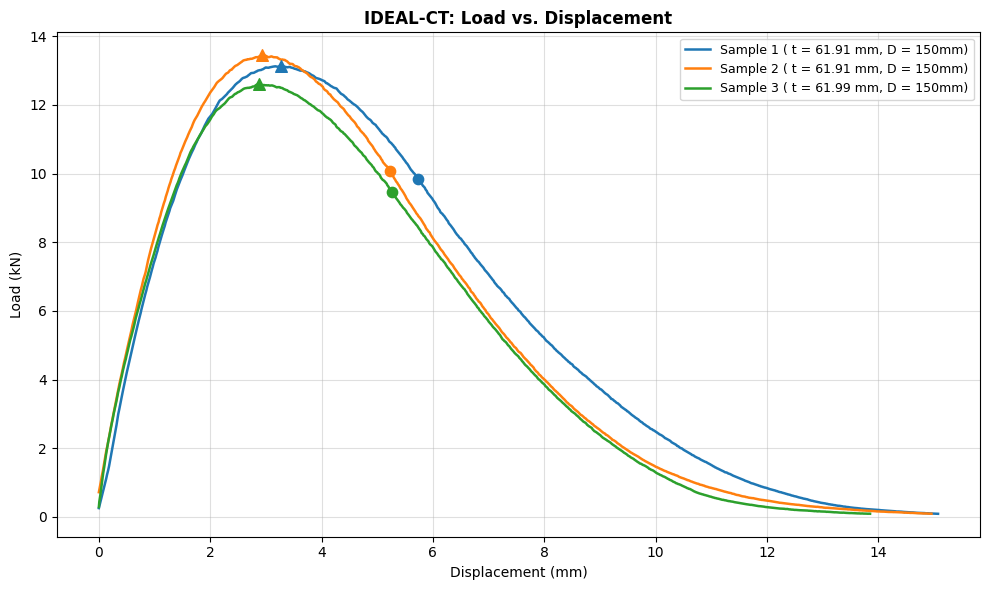

Plot saved to IDEALCT_Load_Displacement.png


In [78]:
# ----- 4. Run CTindex for every sample and plot Load vs. Displacement -----

print("Samples available for plotting:", list(samples.keys()))

ct_results = []

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.tab10.colors

for i, (name, df_s) in enumerate(samples.items()):
    t_mm = sample_meta[name]["Thickness (mm)"]
    D_mm = sample_meta[name]["Diameter (mm)"]

    disp = df_s["Displacement_mm"].values
    load = df_s["Load_kN"].values

    print(f"\n{name}")
    print("Rows:", len(df_s))
    print("First displacement values:", disp[:5])
    print("First load values:", load[:5])

    try:
        res = calc_CTindex(disp, load, t_mm, D_mm)
        res["Sample"] = name
        res["Thickness (mm)"] = t_mm
        ct_results.append(res)

        color = colors[i % len(colors)]

        ax.plot(disp, load, linewidth=1.8, color=color, label=name)
        ax.scatter(res["Peak Disp (mm)"], res["Peak Load (kN)"],
                   color=color, marker='^', s=70, zorder=5)
        ax.scatter(res["l75 (mm)"], res["P75 (kN)"],
                   color=color, marker='o', s=55, zorder=5)

    except Exception as e:
        print(f"{name}: {e}")
        ct_results.append({
            "Sample": name,
            "Thickness (mm)": t_mm,
            "CTindex": f"Error: {e}"
        })

ax.set_xlabel("Displacement (mm)")
ax.set_ylabel("Load (kN)")
ax.set_title("IDEAL-CT: Load vs. Displacement", fontweight="bold")
ax.grid(True, alpha=0.4)

handles, labels = ax.get_legend_handles_labels()
if labels:
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("IDEALCT_Load_Displacement.png", dpi=300, bbox_inches="tight")
plt.show()

print("Plot saved to IDEALCT_Load_Displacement.png")

In [79]:
# ----- 5. Print and export CTindex summary -----

ct_df = pd.DataFrame(ct_results)

col_order = [
    "Sample",
    "Thickness (mm)",
    "Peak Load (kN)",
    "Peak Disp (mm)",
    "P75 (kN)",
    "l75 (mm)",
    "|m75| (kN/mm)",
    "Wf (J)",
    "Gf (J/m²)",
    "CTindex"
]

ct_df = ct_df[[c for c in col_order if c in ct_df.columns]]

print("\n========== IDEAL-CT RESULTS SUMMARY ==========")
print(ct_df.to_string(index=False))

# Export to Excel
ct_df.to_excel("IDEALCT_Results.xlsx", index=False)

print("\nResults saved to IDEALCT_Results.xlsx")


========== IDEAL-CT RESULTS SUMMARY ==========
                             Sample  Thickness (mm)  Peak Load (kN)  Peak Disp (mm)  P75 (kN)  l75 (mm)  |m75| (kN/mm)  Wf (J)  Gf (J/m²)  CTindex
Sample 1 ( t = 61.91 mm, D = 150mm)           61.91          13.139           3.267    9.8542    5.7383       2.055556 87.7784    9452.26 175.6590
Sample 2 ( t = 61.91 mm, D = 150mm)           61.91          13.447           2.937   10.0852    5.2313       2.722222 82.0575    8836.22 113.0385
Sample 3 ( t = 61.99 mm, D = 150mm)           61.99          12.612           2.881    9.4590    5.2666       2.352941 76.9635    8276.98 123.4888

Results saved to IDEALCT_Results.xlsx


In [80]:
# =============================================================
# MODULE D: Rutting Analyzer (HWTT)
# =============================================================

raw_hwtt = pd.read_excel(FILE_PATH, sheet_name='HWTT')
raw_hwtt.columns = raw_hwtt.columns.astype(str).str.strip()

print("HWTT sheet shape:", raw_hwtt.shape)
print("\nColumns:")
print(raw_hwtt.columns.tolist())
print("\nFirst 15 rows:")
print(raw_hwtt.head(15))

HWTT sheet shape: (10001, 6)

Columns:
['Unnamed: 0', 'Pair 1', 'Unnamed: 2', 'Unnamed: 3', 'Pair 2', 'Unnamed: 5']

First 15 rows:
    Unnamed: 0 Pair 1 Unnamed: 2  Unnamed: 3 Pair 2 Unnamed: 5
0          NaN     LC         RD         NaN     LC         RD
1          NaN      2          0         NaN      2          0
2          NaN      4          0         NaN      4          0
3          NaN      6       0.08         NaN      6       0.09
4          NaN      8       0.13         NaN      8       0.16
5          NaN     10       0.19         NaN     10       0.23
6          NaN     12       0.23         NaN     12       0.28
7          NaN     14       0.27         NaN     14       0.33
8          NaN     16       0.31         NaN     16       0.37
9          NaN     18       0.34         NaN     18       0.42
10         NaN     20       0.37         NaN     20       0.46
11         NaN     22       0.39         NaN     22        0.5
12         NaN     24       0.43         NaN     

In [81]:
# ----- 2. Parse individual HWTT samples from the sheet -----

hwtt_samples = {}

# Pair 1
pair1 = raw_hwtt[["Pair 1", "Unnamed: 2"]].copy()
pair1.columns = ["Cycles", "Rut_Depth_mm"]
pair1 = pair1.iloc[1:, :]   # drop LC / RD row
pair1 = pair1.apply(pd.to_numeric, errors='coerce').dropna()

if len(pair1) > 5:
    hwtt_samples["Pair 1"] = pair1.reset_index(drop=True)

# Pair 2
pair2 = raw_hwtt[["Pair 2", "Unnamed: 5"]].copy()
pair2.columns = ["Cycles", "Rut_Depth_mm"]
pair2 = pair2.iloc[1:, :]   # drop LC / RD row
pair2 = pair2.apply(pd.to_numeric, errors='coerce').dropna()

if len(pair2) > 5:
    hwtt_samples["Pair 2"] = pair2.reset_index(drop=True)

print(f"Found {len(hwtt_samples)} HWTT sample(s):")
for name in hwtt_samples:
    print("\n", name)
    print(hwtt_samples[name].head())
    print("Rows:", len(hwtt_samples[name]))

Found 2 HWTT sample(s):

 Pair 1
   Cycles  Rut_Depth_mm
0       2          0.00
1       4          0.00
2       6          0.08
3       8          0.13
4      10          0.19
Rows: 10000

 Pair 2
   Cycles  Rut_Depth_mm
0       2          0.00
1       4          0.00
2       6          0.09
3       8          0.16
4      10          0.23
Rows: 10000


In [60]:
# ----- 3. SIP detection and failure-point functions -----

def find_sip(cycles, rut_depth, min_cycle=2000, smooth_window=25):
    cycles = np.array(cycles, dtype=float)
    rut_depth = np.array(rut_depth, dtype=float)

    mask = ~(np.isnan(cycles) | np.isnan(rut_depth))
    cycles = cycles[mask]
    rut_depth = rut_depth[mask]

    if len(cycles) < 10:
        raise ValueError("Not enough data points for SIP detection.")

    rut_smooth = pd.Series(rut_depth).rolling(
        window=smooth_window, center=True, min_periods=1
    ).mean().to_numpy()

    slope = np.gradient(rut_smooth, cycles)
    slope_change = np.gradient(slope, cycles)

    valid = cycles >= min_cycle
    if not np.any(valid):
        raise ValueError("No cycles beyond minimum SIP search threshold.")

    idx_candidates = np.where(valid)[0]
    idx_sip = idx_candidates[np.argmax(slope_change[idx_candidates])]

    return {
        "SIP Cycles": float(cycles[idx_sip]),
        "SIP Rut Depth (mm)": float(rut_depth[idx_sip])
    }


def find_failure_point(cycles, rut_depth, threshold=12.5):
    cycles = np.array(cycles, dtype=float)
    rut_depth = np.array(rut_depth, dtype=float)

    mask = ~(np.isnan(cycles) | np.isnan(rut_depth))
    cycles = cycles[mask]
    rut_depth = rut_depth[mask]

    crossed = np.where(rut_depth >= threshold)[0]

    if len(crossed) == 0:
        return {
            "Failure Cycles": np.nan,
            "Failure Rut Depth (mm)": np.nan,
            "Failed": False
        }

    idx = crossed[0]

    if idx == 0:
        fail_cycles = cycles[0]
    else:
        x0, y0 = cycles[idx - 1], rut_depth[idx - 1]
        x1, y1 = cycles[idx], rut_depth[idx]

        if y1 == y0:
            fail_cycles = x1
        else:
            fail_cycles = x0 + (threshold - y0) * (x1 - x0) / (y1 - y0)

    return {
        "Failure Cycles": float(fail_cycles),
        "Failure Rut Depth (mm)": float(threshold),
        "Failed": True
    }


def pass_fail_result(failure_cycles, survive_cycles=20000):
    if pd.isna(failure_cycles):
        return "Pass"
    elif failure_cycles >= survive_cycles:
        return "Pass"
    else:
        return "Fail"

print("HWTT functions defined.")

HWTT functions defined.


Samples available for plotting: ['Pair 1', 'Pair 2']


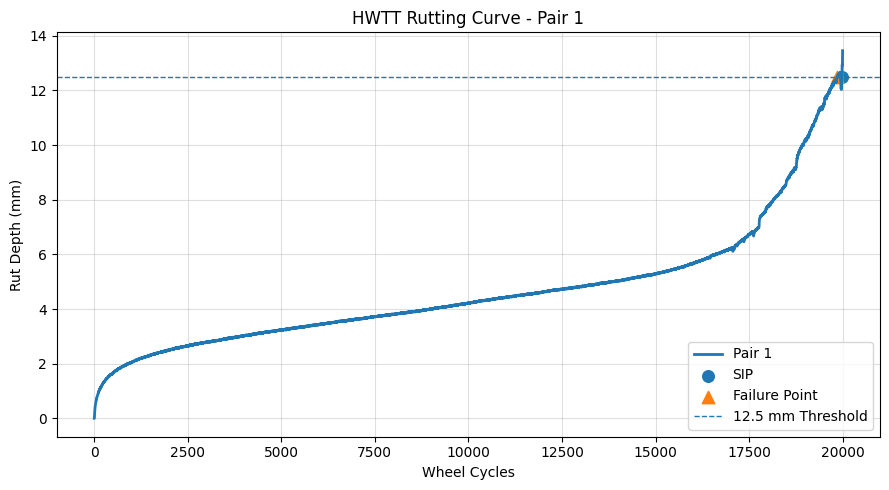

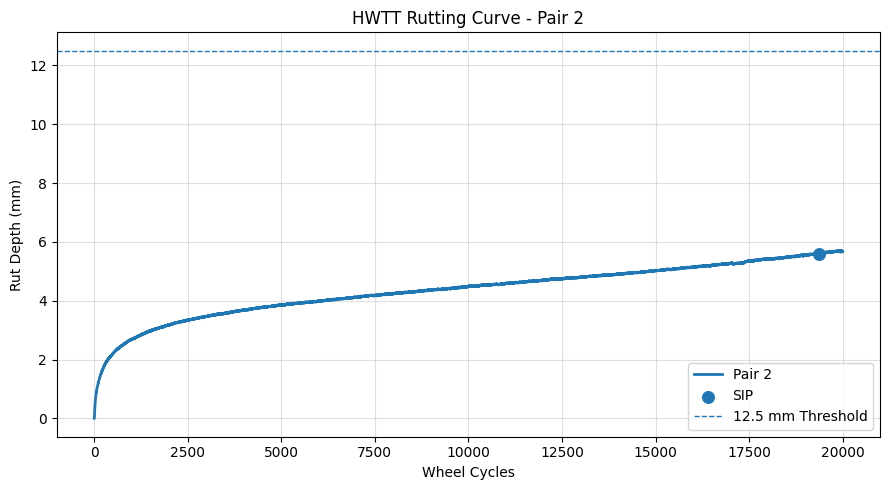

HWTT analysis complete.


In [82]:
# ----- 4. Run HWTT analysis and plot Rut Depth vs. Cycles -----

print("Samples available for plotting:", list(hwtt_samples.keys()))

hwtt_results = []

for name, df_s in hwtt_samples.items():
    cycles = df_s["Cycles"].values
    rut = df_s["Rut_Depth_mm"].values

    try:
        sip = find_sip(cycles, rut)
        failure = find_failure_point(cycles, rut, threshold=12.5)
        pf = pass_fail_result(failure["Failure Cycles"], survive_cycles=20000)

        hwtt_results.append({
            "Sample": name,
            "SIP Cycles": round(sip["SIP Cycles"], 2),
            "SIP Rut Depth (mm)": round(sip["SIP Rut Depth (mm)"], 3),
            "Failure Cycles": round(failure["Failure Cycles"], 2) if not pd.isna(failure["Failure Cycles"]) else np.nan,
            "Failure Rut Depth (mm)": 12.5 if failure["Failed"] else np.nan,
            "Pass/Fail": pf
        })

        plt.figure(figsize=(9, 5))
        plt.plot(cycles, rut, linewidth=2, label=name)

        plt.scatter(
            sip["SIP Cycles"],
            sip["SIP Rut Depth (mm)"],
            s=70,
            marker='o',
            label='SIP'
        )

        if failure["Failed"]:
            plt.scatter(
                failure["Failure Cycles"],
                failure["Failure Rut Depth (mm)"],
                s=80,
                marker='^',
                label='Failure Point'
            )

        plt.axhline(12.5, linestyle='--', linewidth=1, label='12.5 mm Threshold')

        plt.xlabel("Wheel Cycles")
        plt.ylabel("Rut Depth (mm)")
        plt.title(f"HWTT Rutting Curve - {name}")
        plt.legend()
        plt.grid(True, alpha=0.4)
        plt.tight_layout()

        safe_name = re.sub(r'[^A-Za-z0-9]+', '_', name).strip('_')
        plt.savefig(f"HWTT_{safe_name}.png", dpi=300, bbox_inches='tight')
        plt.show()

    except Exception as e:
        print(f"{name}: {e}")
        hwtt_results.append({
            "Sample": name,
            "SIP Cycles": np.nan,
            "SIP Rut Depth (mm)": np.nan,
            "Failure Cycles": np.nan,
            "Failure Rut Depth (mm)": np.nan,
            "Pass/Fail": f"Error: {e}"
        })

print("HWTT analysis complete.")

In [83]:
# ----- 5. Print and export HWTT summary -----

hwtt_df = pd.DataFrame(hwtt_results)

col_order = [
    "Sample",
    "SIP Cycles",
    "SIP Rut Depth (mm)",
    "Failure Cycles",
    "Failure Rut Depth (mm)",
    "Pass/Fail"
]

hwtt_df = hwtt_df[[c for c in col_order if c in hwtt_df.columns]]

print("\n========== HWTT RESULTS SUMMARY ==========")
print(hwtt_df.to_string(index=False))

hwtt_df.to_excel("HWTT_Results.xlsx", index=False)
print("\nResults saved to HWTT_Results.xlsx")


========== HWTT RESULTS SUMMARY ==========
Sample  SIP Cycles  SIP Rut Depth (mm)  Failure Cycles  Failure Rut Depth (mm) Pass/Fail
Pair 1     19972.0               12.49         19860.0                    12.5      Fail
Pair 2     19368.0                5.59             NaN                     NaN      Pass

Results saved to HWTT_Results.xlsx
